In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

─── Neutral-Position Summary ───────────────────────────────
  Attachment points   : ±14.0 m from centreline
  Anchor positions    : ±14.0 m from centreline (seabed)
  Vertical depth h    : 22.5 m
  Geometric length L  : 22.500 m
  Free length L0      : 22.050 m
  Pre-strain ε₀       : 2.04 %
  Pre-tension T₀      : 134639.7 kN
  EA                  : 6597 MN


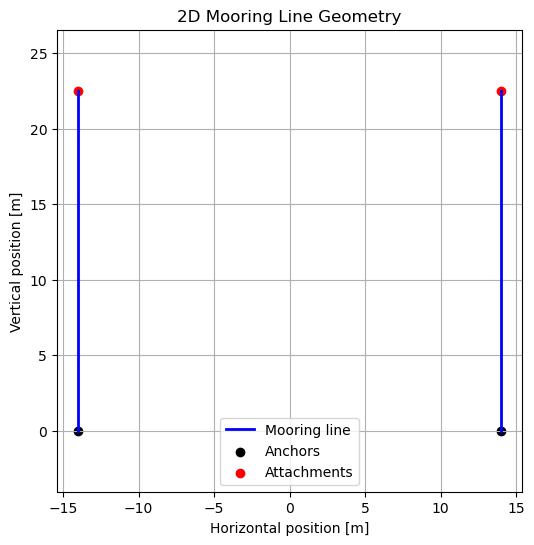

In [35]:
# ── Geometry ──────────────────────────────────────────────────────────────────
B          = 28.0          # Structure width [m]
x_att      = B / 2        # Half-width: horizontal distance attachment → centreline [m]
h          = 22.5          # Vertical distance: attachment point → seabed [m]

# Anchor points are directly below the attachment points (symmetric)
# In the neutral position the attachment point is directly above its anchor.
x_anc      = x_att     # Anchor horizontal position from centreline [m]

# ── Cable properties ──────────────────────────────────────────────────────────
EA = 210000 * np.pi / 4 * 200**2   # Axial stiffness [N]
L0_factor  = 0.98          # Free length as fraction of straight distance → pre-tension

# ── Neutral-position geometry ─────────────────────────────────────────────────
# At equilibrium (no excursion) the cable runs from anchor (±x_anc, 0)
# to attachment point (±x_att, h).  Here x_anc == x_att so the cable is
# perfectly vertical in the neutral position.
L_geo0     = h             # Geometric length in neutral position [m]
L0         = L0_factor * L_geo0   # Unstretched (free) length [m]
epsilon0   = (L_geo0 - L0) / L0   # Pre-strain [-]
T0         = EA * epsilon0         # Pre-tension [N]

print('─── Neutral-Position Summary ───────────────────────────────')
print(f'  Attachment points   : ±{x_att:.1f} m from centreline')
print(f'  Anchor positions    : ±{x_anc:.1f} m from centreline (seabed)')
print(f'  Vertical depth h    : {h:.1f} m')
print(f'  Geometric length L  : {L_geo0:.3f} m')
print(f'  Free length L0      : {L0:.3f} m')
print(f'  Pre-strain ε₀       : {epsilon0*100:.2f} %')
print(f'  Pre-tension T₀      : {T0/1e3:.1f} kN')
print(f'  EA                  : {EA/1e6:.0f} MN')

# Coordinates
# Left side
x_left = [-x_anc, -x_att]
y_left = [0, h]

# Right side
x_right = [x_anc, x_att]
y_right = [0, h]

# Plot
plt.figure(figsize=(6, 6))
plt.plot(x_left, y_left, 'b-', linewidth=2, label='Mooring line')
plt.plot(x_right, y_right, 'b-', linewidth=2)
plt.scatter([-x_anc, x_anc], [0, 0], color='black', label='Anchors')
plt.scatter([-x_att, x_att], [h, h], color='red', label='Attachments')
plt.xlabel('Horizontal position [m]')
plt.ylabel('Vertical position [m]')
plt.title('2D Mooring Line Geometry')
plt.legend()
plt.grid()
plt.axis('equal')

plt.show()

## 2  Core Cable Mechanics

For a **taut cable** (inextensible sag neglected, elastic elongation only) the tension is:

$$T = EA \cdot \frac{L - L_0}{L_0}, \quad L_0 < L$$

The current geometric length of the cable depends on the displaced position $(\Delta x, \Delta z)$ of the attachment point relative to its neutral position:

$$L = \sqrt{(x_{anc} - x_{att} - \Delta x)^2 + (h + \Delta z)^2}$$

where $\Delta x$ is positive towards the opposite anchor and $\Delta z$ is positive upward.

In [36]:
def cable_length(dx_struct, dz_struct, side='port'):
    """
    Geometric length of one cable given the structural displacement.
    side = 'port'  → left  cable  (attachment at -x_att, anchor at -x_anc)
    side = 'starboard' → right cable (attachment at +x_att, anchor at +x_anc)
    dx_struct: positive = rightward displacement of structure centre
    dz_struct: positive = upward displacement of structure
    """
    sign = -1 if side == 'port' else +1
    # Vector from anchor to attachment point in displaced state
    dx_cable = sign * x_att + dx_struct - sign * x_anc   # horizontal component
    dz_cable = h + dz_struct                              # vertical component
    return np.sqrt(dx_cable**2 + dz_cable**2)


def cable_tension(dx_struct, dz_struct, side='port'):
    """Tension in the cable [N]. Zero if cable would go slack."""
    L = cable_length(dx_struct, dz_struct, side)
    strain = (L - L0) / L0
    return max(0.0, EA * strain)


def cable_direction(dx_struct, dz_struct, side='port'):
    """
    Unit vector FROM anchor TO attachment point.
    Returns (cos_theta_h, cos_theta_v) = (horizontal, vertical) direction cosines.
    """
    sign = -1 if side == 'port' else +1
    dx_cable = sign * x_att + dx_struct - sign * x_anc
    dz_cable = h + dz_struct
    L = np.sqrt(dx_cable**2 + dz_cable**2)
    return dx_cable / L, dz_cable / L


def total_restoring_force(dx_struct, dz_struct):
    """
    Net restoring force on the structure [N] for a given displacement.
    Returns (Fx, Fz) where positive Fx is rightward, positive Fz is upward.
    The restoring force opposes the displacement, so sign is defined as
    the net cable force acting on the structure (anchor pulls attachment inward/downward).
    """
    Fx = 0.0
    Fz = 0.0
    for side in ('port', 'starboard'):
        T  = cable_tension(dx_struct, dz_struct, side)
        ch, cv = cable_direction(dx_struct, dz_struct, side)
        # Force ON structure from cable acts from attachment toward anchor → reverse direction
        Fx += -T * ch
        Fz += -T * cv
    return Fx, Fz

# Quick sanity check at neutral position
Fx0, Fz0 = total_restoring_force(0, 0)
print(f'Neutral position net force: Fx = {Fx0/1e3:.3f} kN,  Fz = {Fz0/1e3:.3f} kN')
print(f'(Both should be ~0 N for symmetric vertical geometry)')
print(f'Pre-tension each cable: {cable_tension(0, 0, "port")/1e3:.2f} kN')

Neutral position net force: Fx = 0.000 kN,  Fz = -269279.370 kN
(Both should be ~0 N for symmetric vertical geometry)
Pre-tension each cable: 134639.69 kN


## Horizontal Excursion (surge) ##

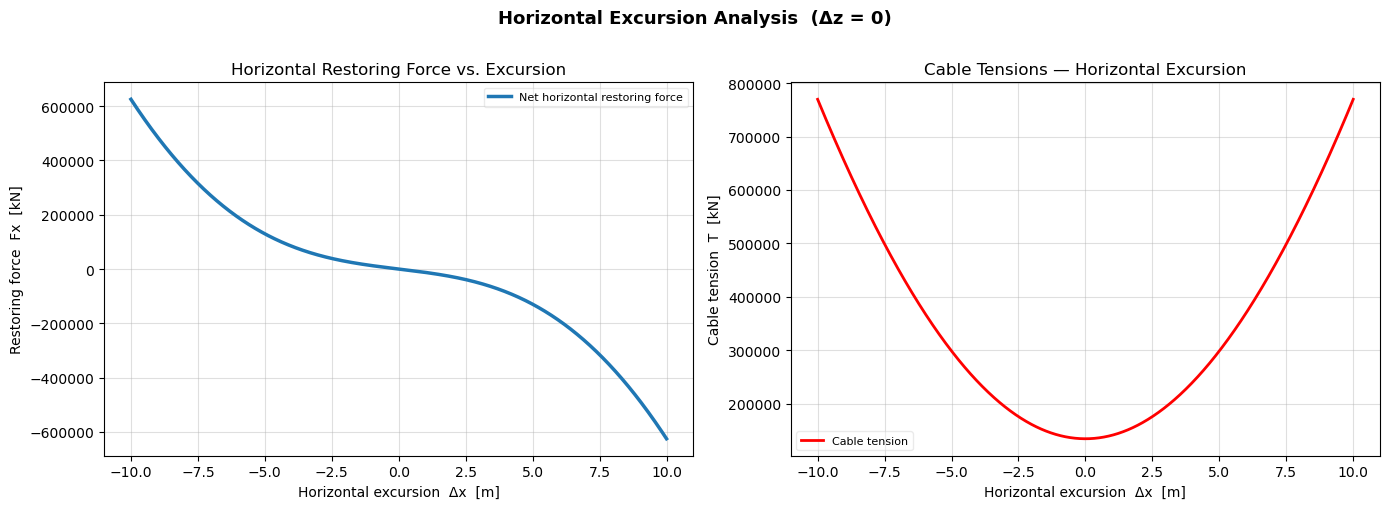

In [37]:
# Sweep horizontal excursion; vertical displacement = 0
dx_range = np.linspace(-10, 10, 1000)
Fx_horiz = np.array([total_restoring_force(dx, 0)[0] for dx in dx_range])
T_h   = np.array([cable_tension(dx, 0, 'port')      for dx in dx_range])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Net restoring force ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(dx_range, Fx_horiz / 1e3, lw=2.5, label='Net horizontal restoring force')
ax.set_xlabel('Horizontal excursion  Δx  [m]')
ax.set_ylabel('Restoring force  Fx  [kN]')
ax.set_title('Horizontal Restoring Force vs. Excursion')
ax.legend(fontsize=8, framealpha=0.4)
ax.grid(True, alpha=0.4)

# ── Right: Individual cable tensions ─────────────────────────────────────────
ax = axes[1]
ax.plot(dx_range, T_h / 1e3,  color='r',    lw=2, label='Cable tension')
ax.set_xlabel('Horizontal excursion  Δx  [m]')
ax.set_ylabel('Cable tension  T  [kN]')
ax.set_title('Cable Tensions — Horizontal Excursion')
ax.legend(fontsize=8, framealpha=0.4)
ax.grid(True, alpha=0.4)

plt.suptitle('Horizontal Excursion Analysis  (Δz = 0)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Vertical excursion (Heave) ##

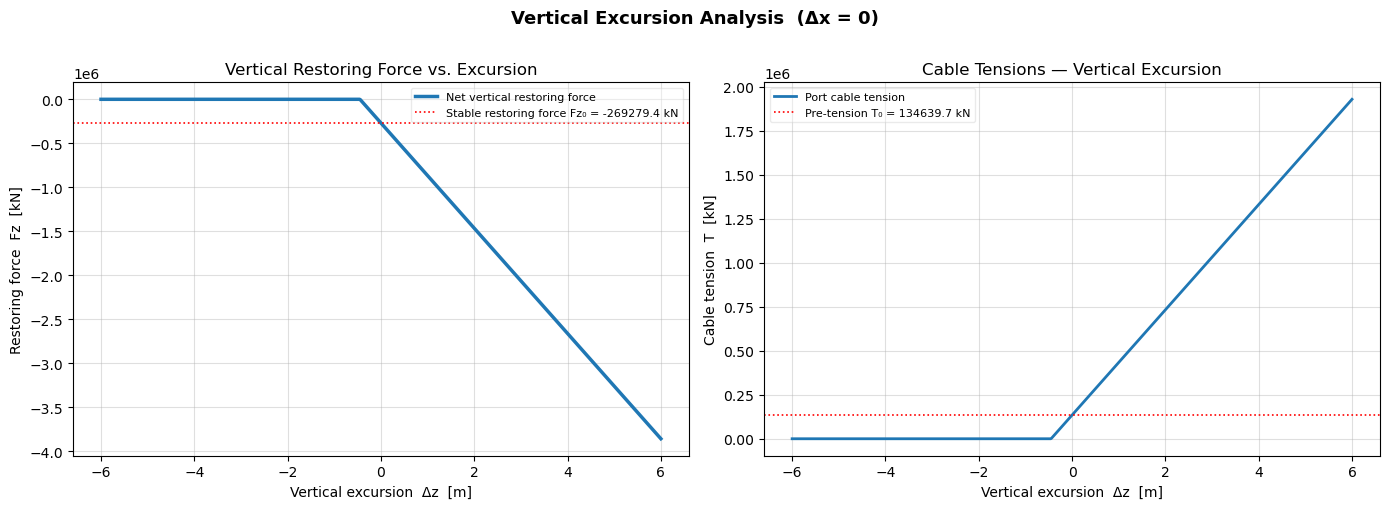

In [38]:
# Sweep vertical excursion; horizontal displacement = 0
dz_range = np.linspace(-6, 6, 800)
Fz_vert  = np.array([total_restoring_force(0, dz)[1] for dz in dz_range])
T_port_v = np.array([cable_tension(0, dz, 'port')      for dz in dz_range])
T_star_v = np.array([cable_tension(0, dz, 'starboard') for dz in dz_range])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(dz_range, Fz_vert / 1e3, lw=2.5, label='Net vertical restoring force')
ax.axhline(Fz0 / 1e3, color='r', lw=1.2, ls=':', label=f'Stable restoring force Fz₀ = {Fz0/1e3:.1f} kN')
ax.set_xlabel('Vertical excursion  Δz  [m]')
ax.set_ylabel('Restoring force  Fz  [kN]')
ax.set_title('Vertical Restoring Force vs. Excursion')
ax.legend(fontsize=8, framealpha=0.4)
ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(dz_range, T_port_v / 1e3,   lw=2, label='Port cable tension')
ax.axhline(T0 / 1e3, color='r', lw=1.2, ls=':', label=f'Pre-tension T₀ = {T0/1e3:.1f} kN')
# ax.axvline(0, color=GRAY, lw=0.8, ls='--')
ax.set_xlabel('Vertical excursion  Δz  [m]')
ax.set_ylabel('Cable tension  T  [kN]')
ax.set_title('Cable Tensions — Vertical Excursion')
ax.legend(fontsize=8, framealpha=0.4)
ax.grid(True, alpha=0.4)

plt.suptitle('Vertical Excursion Analysis  (Δx = 0)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5  Stiffness Diagrams

Stiffness is computed as the numerical derivative of the restoring force:

$$k_x(\Delta x) = -\frac{\partial F_x}{\partial \Delta x}, \qquad k_z(\Delta z) = -\frac{\partial F_z}{\partial \Delta z}$$

> Positive stiffness means the system provides a restoring force opposing the displacement (stable mooring).

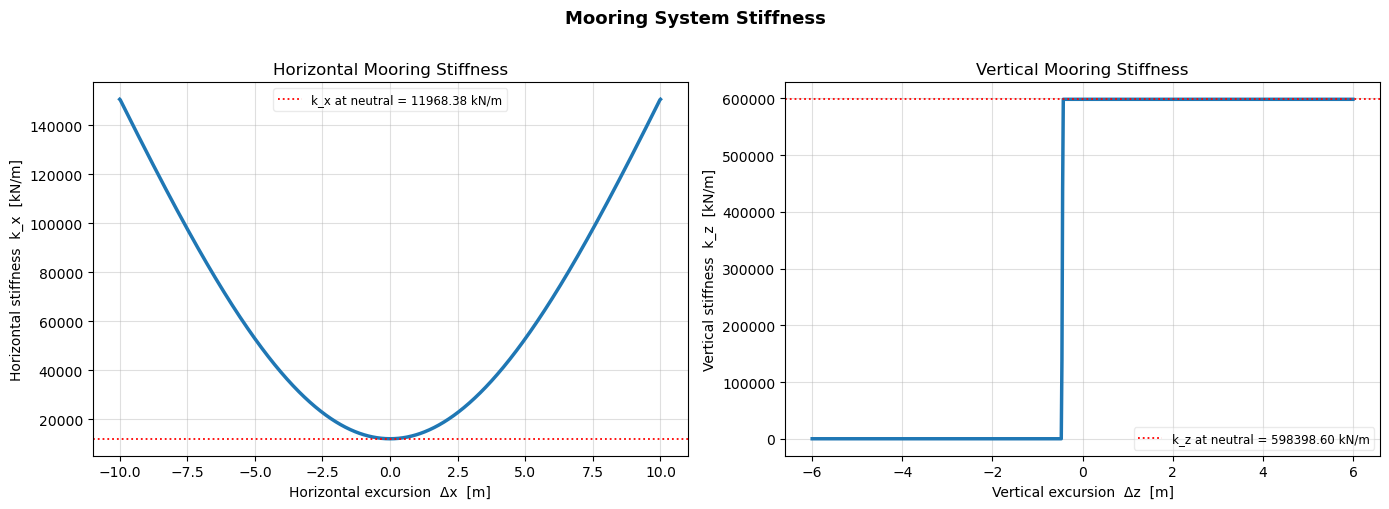

In [39]:
# Numerical differentiation
kx = -np.gradient(Fx_horiz, dx_range)   # [N/m]
kz = -np.gradient(Fz_vert,  dz_range)   # [N/m]

# Stiffness at neutral position
idx0_x = np.argmin(np.abs(dx_range))
idx0_z = np.argmin(np.abs(dz_range))
kx0 = kx[idx0_x]
kz0 = kz[idx0_z]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Horizontal stiffness ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(dx_range, kx / 1e3, lw=2.5)
# ax.axvline(0, color=GRAY, lw=0.8, ls='--')
# ax.axhline(0, color=GRAY, lw=0.8, ls='--')
ax.axhline(kx0 / 1e3, color='r', lw=1.3, ls=':',
           label=f'k_x at neutral = {kx0/1e3:.2f} kN/m')
# ax.fill_between(dx_range, kx / 1e3, 0, alpha=0.12, color=TEAL)
ax.set_xlabel('Horizontal excursion  Δx  [m]')
ax.set_ylabel('Horizontal stiffness  k_x  [kN/m]')
ax.set_title('Horizontal Mooring Stiffness')
ax.legend(fontsize=8.5, framealpha=0.4)
ax.grid(True, alpha=0.4)

# ── Vertical stiffness ────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(dz_range, kz / 1e3, lw=2.5)
# ax.axvline(0, color=GRAY, lw=0.8, ls='--')
# ax.axhline(0, color=GRAY, lw=0.8, ls='--')
ax.axhline(kz0 / 1e3, color='r', lw=1.3, ls=':',
           label=f'k_z at neutral = {kz0/1e3:.2f} kN/m')
# ax.fill_between(dz_range, kz / 1e3, 0, alpha=0.12, color=GREEN)
ax.set_xlabel('Vertical excursion  Δz  [m]')
ax.set_ylabel('Vertical stiffness  k_z  [kN/m]')
ax.set_title('Vertical Mooring Stiffness')
ax.legend(fontsize=8.5, framealpha=0.4)
ax.grid(True, alpha=0.4)

plt.suptitle('Mooring System Stiffness', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7  Analytical Stiffness Derivation (at neutral position)

For the symmetric vertical configuration (anchors directly below attachment points) the linearised stiffness coefficients at the neutral position can be derived analytically.

Each cable carries pre-tension $T_0$ and is vertical ($\theta = 90°$ from horizontal). The horizontal stiffness comes from the geometric change in direction, and the vertical stiffness from the elastic elongation.

In [40]:
# ── Analytical linearised stiffness (two vertical taut cables) ────────────────
#
# At neutral position each cable is vertical.
#
# Horizontal (geometric) stiffness — per cable:
#   When structure moves Δx, the cable tilts.  The horizontal component of
#   tension provides a restoring moment.  For small angles:
#     dFx/dΔx|₀ = T₀ / h   (geometric contribution per cable)
#
# Both cables contribute the SAME sign when structure displaces horizontally:
#   k_x_analytic = 2 * T0 / h
#
# Vertical (elastic) stiffness — per cable:
#   When structure moves Δz, both cables elongate equally.
#   dL/dΔz = 1  (vertical cable, unit vertical motion = unit length change)
#   dT/dΔz = EA/L0
#   Vertical force = T * cos(θ) ≈ T  (vertical cable)
#   k_z_analytic = 2 * EA / L0

kx_analytic = 2 * T0 / h
kz_analytic = 2 * EA / L0

print('─── Analytical vs. Numerical Linearised Stiffness ──────────────────────')
print(f'  Horizontal stiffness  k_x:')
print(f'    Analytical : {kx_analytic/1e3:>10.3f} kN/m')
print(f'    Numerical  : {kx0/1e3:>10.3f} kN/m')
print()
print(f'  Vertical stiffness  k_z:')
print(f'    Analytical : {kz_analytic/1e3:>10.3f} kN/m')
print(f'    Numerical  : {kz0/1e3:>10.3f} kN/m')
print()
print('─── Natural Periods (assuming added mass = structural mass m) ───────────')
m_struct = 1000e3   # Example: 1000 t structural mass [kg]
Ca       = 1.0      # Added mass coefficient (simplified)
m_total  = m_struct * (1 + Ca)
T_surge  = 2 * np.pi * np.sqrt(m_total / kx0)
T_heave  = 2 * np.pi * np.sqrt(m_total / kz0)
print(f'  Assumed structural mass  : {m_struct/1e3:.0f} t')
print(f'  Total mass (incl. Ca=1) : {m_total/1e3:.0f} t')
print(f'  Natural period surge    : {T_surge:.2f} s')
print(f'  Natural period heave    : {T_heave:.2f} s')

─── Analytical vs. Numerical Linearised Stiffness ──────────────────────
  Horizontal stiffness  k_x:
    Analytical :  11967.972 kN/m
    Numerical  :  11968.378 kN/m

  Vertical stiffness  k_z:
    Analytical : 598398.601 kN/m
    Numerical  : 598398.601 kN/m

─── Natural Periods (assuming added mass = structural mass m) ───────────
  Assumed structural mass  : 1000 t
  Total mass (incl. Ca=1) : 2000 t
  Natural period surge    : 2.57 s
  Natural period heave    : 0.36 s


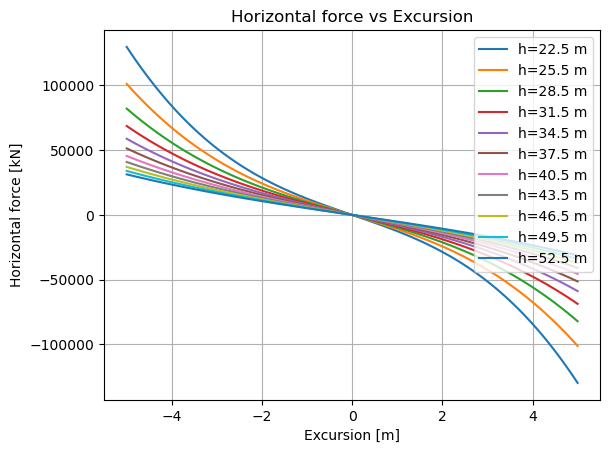

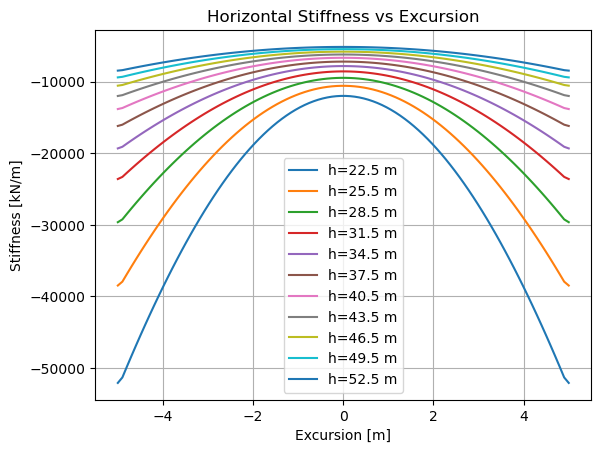

In [41]:
depths = np.arange(22.5, 52.5 + 0.1, 3.0)

excursions = np.linspace(-5, 5, 100)

all_Fx_horiz = []
all_stiffness = []

for h in depths:
    L_geo0 = h
    L0 = L0_factor * L_geo0

    Fx_horiz = []

    for dx in excursions:
        Fx_horiz.append(total_restoring_force(dx, 0)[0])
        # # New geometry (one side, symmetric)
        # dx = x_att + x - x_anc
        # L = np.sqrt(dx**2 + h**2)

        # strain = (L - L0) / L0
        # T = EA * strain if strain > 0 else 0
        # tensions.append(T)

    Fx_horiz = np.array(Fx_horiz)
    stiffness = np.gradient(Fx_horiz, excursions)

    all_Fx_horiz.append(Fx_horiz)
    all_stiffness.append(stiffness)

# Plot results
plt.figure()
for i, h in enumerate(depths):
    plt.plot(excursions, all_Fx_horiz[i]/1000, label=f"h={h:.1f} m")
plt.title("Horizontal force vs Excursion")
plt.xlabel("Excursion [m]")
plt.ylabel("Horizontal force [kN]")
plt.legend()
plt.grid()
plt.show()

plt.figure()
for i, h in enumerate(depths):
    plt.plot(excursions, all_stiffness[i]/1000, label=f"h={h:.1f} m")
plt.title("Horizontal Stiffness vs Excursion")
plt.xlabel("Excursion [m]")
plt.ylabel("Stiffness [kN/m]")
plt.legend()
plt.grid()
plt.show()
